In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
import os
print(os.listdir("../data/processed"))

['01_fund_master.csv', '01_fund_master_clean.csv', '02_nav_history.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows.csv', '05_category_inflows_clean.csv', '06_industry_folio_count.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance.csv', '07_scheme_performance_clean.csv', '08_investor_transactions.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices.csv', '10_benchmark_indices_clean.csv']


In [104]:
fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

print("FUND:", fund.shape)
print("NAV:", nav.shape)
print("TXN:", txn.shape)
print("PORTFOLIO:", portfolio.shape)

FUND: (40, 15)
NAV: (46000, 3)
TXN: (32778, 13)
PORTFOLIO: (322, 8)


In [105]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [106]:
nav['date'] = pd.to_datetime(nav['date'])
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

print("Done")

Done


In [107]:
var_results = []

for code in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == code].copy()
    temp = temp.sort_values('date')

    temp['returns'] = temp['nav'].pct_change()

    returns = temp['returns'].dropna()

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    var_results.append([code, var95, cvar95])

var_cvar = pd.DataFrame(
    var_results,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [108]:
var_cvar.to_csv("var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved")

var_cvar_report.csv saved


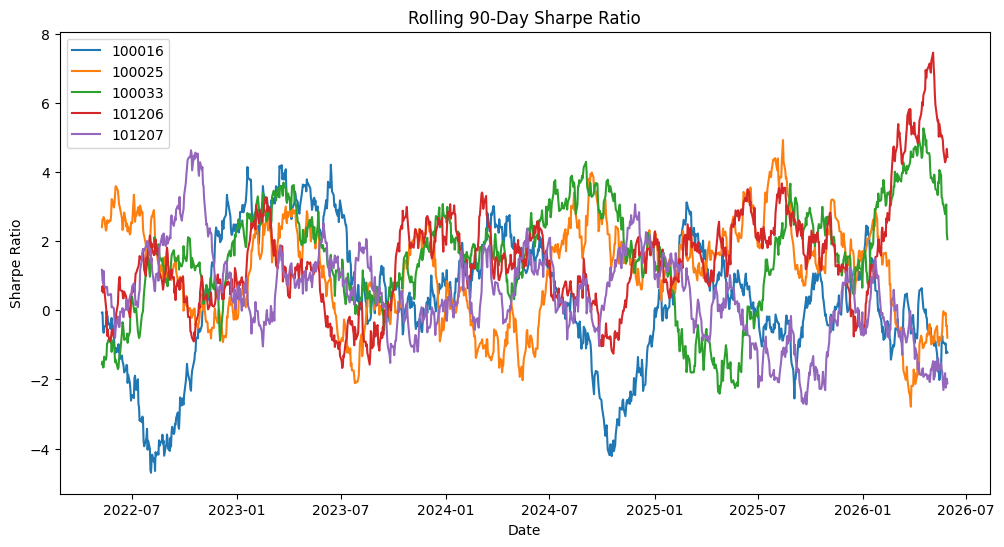

In [109]:
sample_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for code in sample_funds:

    temp = nav[nav['amfi_code']==code].copy()

    temp = temp.sort_values('date')

    temp['returns'] = temp['nav'].pct_change()

    temp['rolling_sharpe'] = (
        temp['returns'].rolling(90).mean()
        /
        temp['returns'].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.show()

In [110]:
plt.savefig("rolling_sharpe_chart.png")
print("Chart saved")

Chart saved


<Figure size 640x480 with 0 Axes>

In [111]:
txn['cohort_year'] = txn.groupby(
    'investor_id'
)['transaction_date'].transform('min').dt.year

cohort = txn.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr','mean'),
    total_invested=('amount_inr','sum')
)

cohort

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [112]:
sip = txn[
    txn['transaction_type'].str.contains(
        'sip',
        case=False,
        na=False
    )
]

risk_list = []

for investor, group in sip.groupby('investor_id'):

    if len(group) >= 6:

        group = group.sort_values('transaction_date')

        avg_gap = (
            group['transaction_date']
            .diff()
            .dt.days
            .mean()
        )

        status = (
            "At Risk"
            if avg_gap > 35
            else "Healthy"
        )

        risk_list.append(
            [investor, avg_gap, status]
        )

sip_continuity = pd.DataFrame(
    risk_list,
    columns=[
        'investor_id',
        'avg_gap_days',
        'status'
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [113]:
sip_continuity.to_csv(
    "sip_continuity.csv",
    index=False
)

print("Saved")

Saved


In [114]:
hhi = portfolio.groupby(
    'amfi_code'
)['weight_pct'].apply(
    lambda x: ((x/100)**2).sum()
)

hhi = hhi.reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.sort_values(
    'HHI',
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [115]:
hhi.to_csv(
    "sector_hhi.csv",
    index=False
)

print("HHI saved")

HHI saved


In [116]:
fund.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [117]:
fund.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [118]:
sharpe = pd.read_csv("sharpe_results.csv")

recommend_df = fund.merge(
    sharpe,
    on="amfi_code"
)

recommend_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,sharpe_ratio
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,304.483175
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,240.226433
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,238.217681
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,-14.411030
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,-57.096997


In [123]:
for risk in recommend_df['risk_category'].unique():

    print("\n")
    print("="*50)
    print(f"TOP FUNDS FOR {risk}")
    print("="*50)

    display(
        recommend_df[
            recommend_df['risk_category']==risk
        ]
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )[
            ['scheme_name',
             'risk_category',
             'sharpe_ratio']
        ]
        .head(3)
    )



TOP FUNDS FOR Moderate


,scheme_name,risk_category,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,364.969375
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,304.483175
15,Nippon India Large Cap Fund - Regular - Growth,Moderate,272.578113




TOP FUNDS FOR Very High


,scheme_name,risk_category,sharpe_ratio
39,DSP Small Cap Fund - Regular - Growth,Very High,239.348548
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,238.217681
17,Nippon India Small Cap Fund - Regular - Growth,Very High,113.005370




TOP FUNDS FOR Low


,scheme_name,risk_category,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,124.922295
23,Kotak Liquid Fund - Regular - Growth,Low,-22.364319
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-57.096997




TOP FUNDS FOR High


,scheme_name,risk_category,sharpe_ratio
36,Mirae Asset Tax Saver Fund - Regular - Growth,High,311.202366
12,ICICI Pru Midcap Fund - Regular - Growth,High,297.385502
38,DSP Midcap Fund - Regular - Growth,High,285.294707




TOP FUNDS FOR Moderately High


,scheme_name,risk_category,sharpe_ratio
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,329.299480
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately High,233.424411
13,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,163.517451


In [121]:
sharpe.columns.tolist()

['amfi_code', 'sharpe_ratio']

## Insight 1

Funds with the most negative VaR values exhibit the highest downside risk under normal market conditions.

## Insight 2

Recent investor cohorts contributed a significant share of total investments, indicating growing retail participation in mutual funds.

## Insight 3

Most SIP investors maintain regular investment intervals, while a smaller segment is classified as at-risk due to delayed contributions.

## Insight 4

Funds with higher Sharpe Ratios consistently deliver stronger risk-adjusted performance compared to their peers.

## Insight 5

Higher HHI scores indicate concentrated portfolios, whereas lower HHI scores suggest broader diversification across sectors.